# SI — Sensitivity to the initial knowledge stock `N0`

Produces `figures/fig_SI5.pdf` from the scan stored in
`sim_runs/<dataset>/n0_grid_results.csv`, which is written by
`module_4_n0_search.ipynb`. This notebook only reads the scan, so unlike the
other SI notebooks it runs without the raw data.


In [1]:
# Repository bootstrap.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "lib").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "lib"))

FIGURE_DIR = REPO_ROOT / "figures"               # manuscript figures, versioned
SIM_RUNS_DIR = REPO_ROOT / "sim_runs"            # model runs (N0 scan and selected run)


## Imports and style


In [2]:
import json

import pandas as pd
import matplotlib.pyplot as plt

from plot_style import apply_si_style, DIST_COLORS, SI_DATA_LW, SI_REF_LW

apply_si_style()
colors_dist = dict(DIST_COLORS)

pd.set_option("display.max_columns", 60)


## The figure

Combined log-RMSE against `N0` for both datasets, with the selected value
marked. The point of the panel is that the minimum sits in a flat basin: the
calibration is not sensitive to the exact value of `N0`.


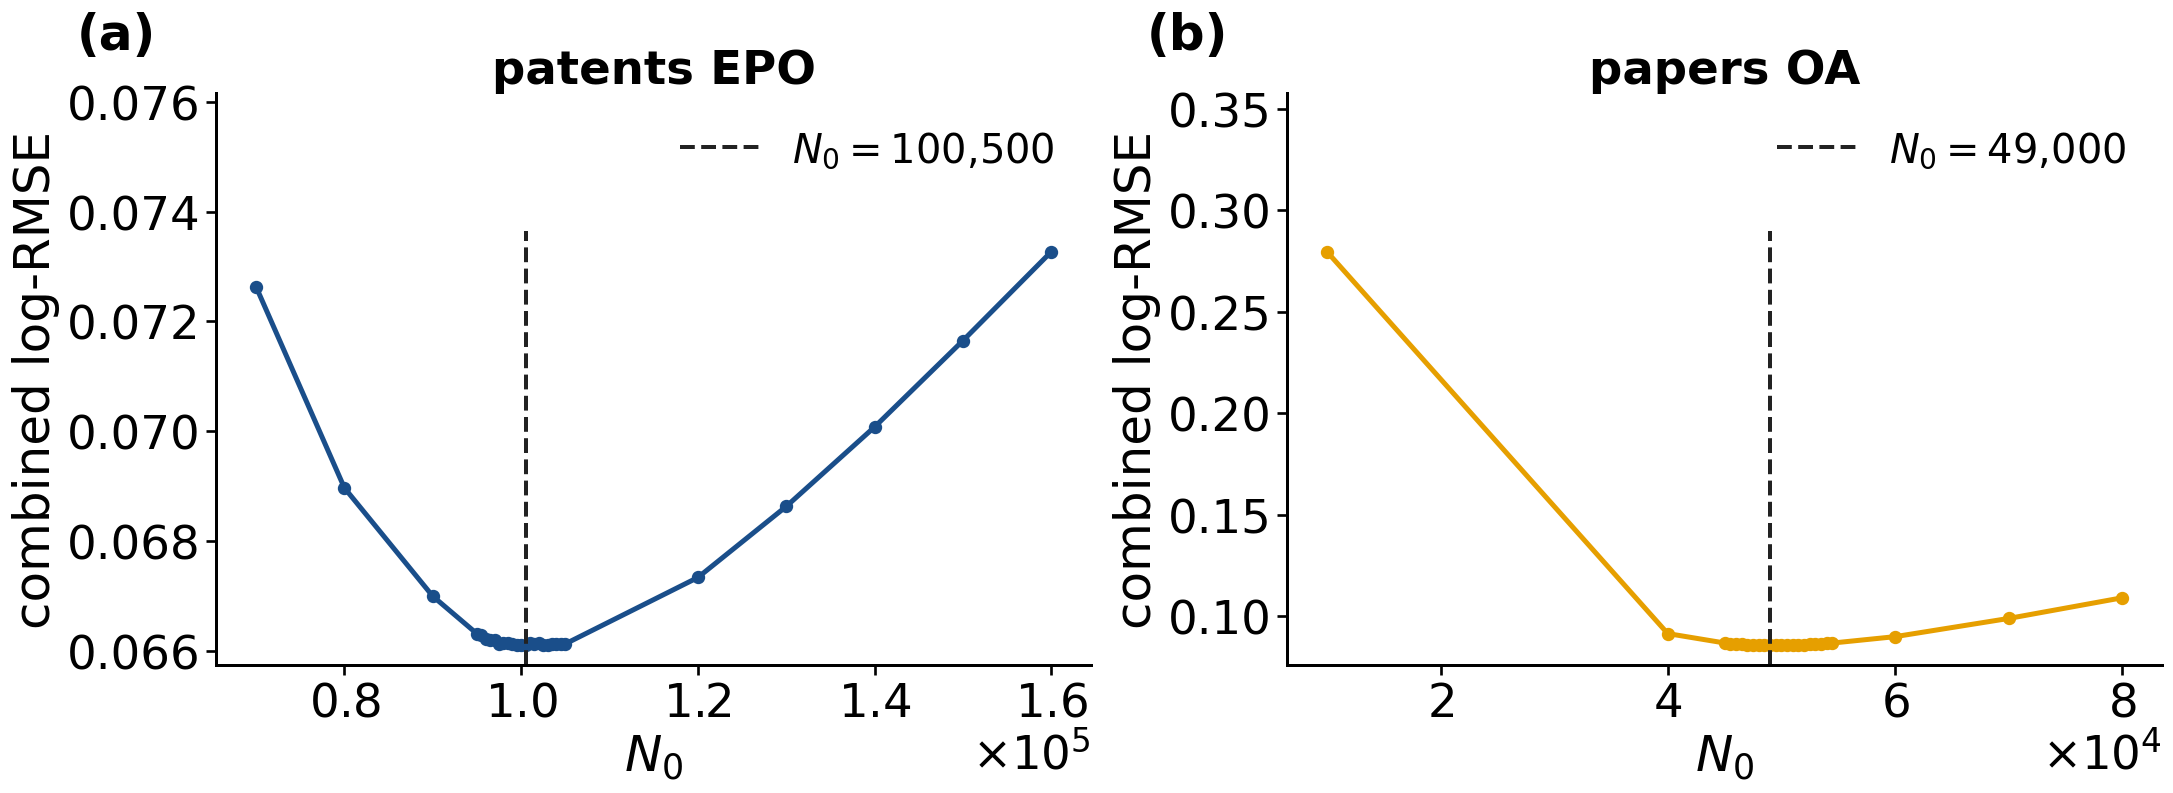

figure -> figures/fig_SI5.pdf
{'patents': {'best_N0': 100500, 'best_score': 0.0661089293442128, 'n_grid': 29}, 'papers': {'best_N0': 49000, 'best_score': 0.085634254476927, 'n_grid': 25}}


In [3]:
# The scan combines a broad grid with a 500-unit refinement around the optimum.
# The selected N0 is the minimiser of the combined log-RMSE on D and D_w, and is
# cross-checked here against best_n0_run.json.
N0_SCAN_DIR = SIM_RUNS_DIR
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_TITLE = {"patents": "patents EPO", "papers": "papers OA"}
DATASET_COLOR = {"patents": colors_dist["patents"], "papers": colors_dist["papers"]}

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), constrained_layout=True)
n0_selection = {}

for col_idx, name in enumerate(["patents", "papers"]):
    scan = pd.read_csv(N0_SCAN_DIR / name / "n0_grid_results.csv")
    scan = scan.sort_values("N0").reset_index(drop=True)
    best_row = scan.loc[scan["rmse_log_total"].idxmin()]
    best_N0 = int(best_row["N0"])
    with open(N0_SCAN_DIR / name / "best_n0_run.json") as handle:
        recorded_N0 = int(json.load(handle)["best_N0"])
    assert best_N0 == recorded_N0, (name, best_N0, recorded_N0)
    n0_selection[name] = {"best_N0": best_N0,
                          "best_score": float(best_row["rmse_log_total"]),
                          "n_grid": int(len(scan))}

    ax = axes[col_idx]
    ax.plot(scan["N0"], scan["rmse_log_total"], marker="o", ms=7.0,
            lw=SI_DATA_LW, color=DATASET_COLOR[name])
    # The marker of the selected N0 stops below the legend band: the legend sits
    # in the headroom added above the curve, and the guide would run into it.
    ax.axvline(best_N0, ymax=0.76, ls="--", lw=SI_REF_LW,
               color=colors_dist["reference"],
               label=r"$N_0 = %s$" % format(best_N0, ",d").replace(",", "{,}"))
    ax.set_xlabel(r"$N_0$")
    ax.set_ylabel("combined log-RMSE")
    ax.set_title(DATASET_TITLE[name], fontsize=28, fontweight="bold")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
    # Headroom above the curve, so the legend clears both the trace and its
    # markers on the rising arm.
    _ylo, _yhi = ax.get_ylim()
    ax.set_ylim(top=_yhi + 0.32 * (_yhi - _ylo))
    ax.legend(loc="upper right", frameon=False, fontsize=24)
    ax.text(-0.16, 1.06, "(a)" if col_idx == 0 else "(b)", transform=ax.transAxes,
            va="bottom", ha="left", fontsize=30, fontweight="bold")

fig.savefig(FIGURE_DIR / "fig_SI5.pdf", format="pdf", facecolor="white")
plt.show()
print("figure ->", (FIGURE_DIR / "fig_SI5.pdf").relative_to(REPO_ROOT))
print(n0_selection)
